# Experiment: K-Armed Bandits

This notebook compares three standard bandit baselines:
- epsilon-greedy action selection
- optimistic initial values vs UCB
- gradient bandit methods


In [2]:
from __future__ import annotations

import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "agents").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / ".mplconfig"))

from agents.bandits import EpsilonGreedy, GradientBandit, UCB
from envs.k_bandits import KArmedBandit
from experiments.bandits import run_experiment
from plots.bandits import plot_reward_curves


## Parameters

- `steps`: number of actions per run
- `runs`: number of independent runs averaged together
- `k`: number of arms


In [3]:
STEPS = 1000
RUNS = 2000
K = 10
SEED = 7

STEPS, RUNS, K, SEED


(1000, 2000, 10, 7)

## 1. Epsilon-Greedy Comparison

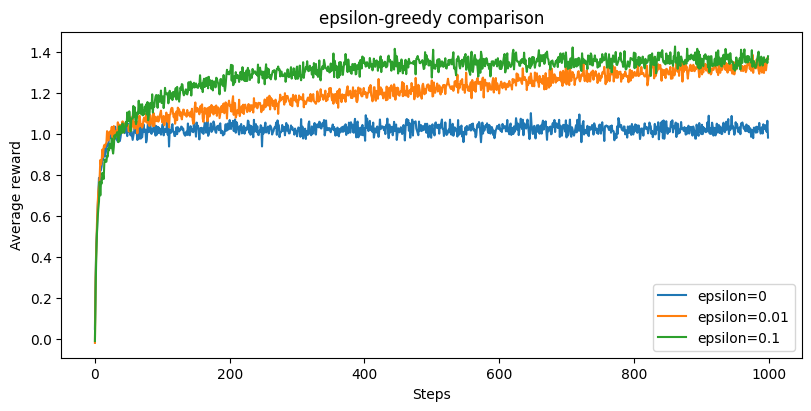

In [4]:
env = KArmedBandit(k=K, seed=SEED)
epsilon_curves = {}

for eps in (0.0, 0.01, 0.1):
    agent = EpsilonGreedy(k=K, epsilon=eps, seed=SEED)
    rewards, _ = run_experiment(agent, env, steps=STEPS, runs=RUNS)
    epsilon_curves[f"epsilon={eps:g}"] = rewards

fig, ax = plot_reward_curves(epsilon_curves, title="epsilon-greedy comparison")
plt.show()


## 2. Optimistic Initial Values vs UCB

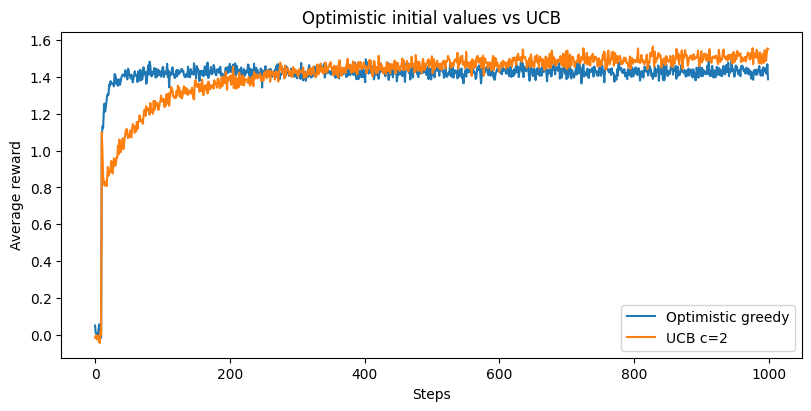

In [5]:
env = KArmedBandit(k=K, seed=SEED)
optimistic_ucb_curves = {}

agents = {
    "Optimistic greedy": EpsilonGreedy(k=K, epsilon=0.0, optimistic=5.0, seed=SEED),
    "UCB c=2": UCB(k=K, c=2.0, seed=SEED),
}

for label, agent in agents.items():
    rewards, _ = run_experiment(agent, env, steps=STEPS, runs=RUNS)
    optimistic_ucb_curves[label] = rewards

fig, ax = plot_reward_curves(optimistic_ucb_curves, title="Optimistic initial values vs UCB")
plt.show()


## 3. Gradient Bandit Methods

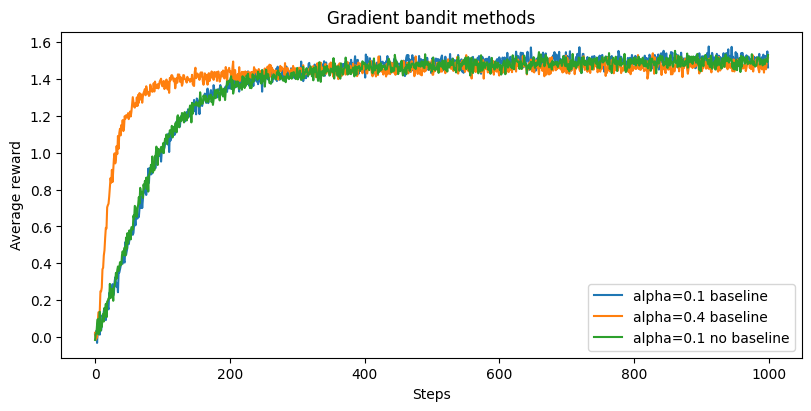

In [6]:
env = KArmedBandit(k=K, seed=SEED)
gradient_curves = {}

agents = {
    "alpha=0.1 baseline": GradientBandit(k=K, alpha=0.1, baseline=True, seed=SEED),
    "alpha=0.4 baseline": GradientBandit(k=K, alpha=0.4, baseline=True, seed=SEED),
    "alpha=0.1 no baseline": GradientBandit(k=K, alpha=0.1, baseline=False, seed=SEED),
}

for label, agent in agents.items():
    rewards, _ = run_experiment(agent, env, steps=STEPS, runs=RUNS)
    gradient_curves[label] = rewards

fig, ax = plot_reward_curves(gradient_curves, title="Gradient bandit methods")
plt.show()
